# Bootcamp Final Quiz

**Time Limit:** 60 minutes  
**Total Points:** 100  
**Format:** Open Internet — you may use Google, Stack Overflow, documentation, etc.  

---

### Rules
1. All code cells **must run without errors** when submitted
2. Write your markdown/text answers in the designated cells
3. Do **not** modify the Setup cell below
4. Questions build on each other — complete them in order
5. Read each question carefully before answering

### Grading Breakdown
| Section | Topic | Points |
|---------|-------|--------|
| 1 | Concepts & Warm-Up | 15 |
| 2 | Linear Regression & Metrics | 15 |
| 3 | Logistic Regression & Classification | 25 |
| 4 | Tree-Based Models | 25 |
| 5 | Model Pipeline & Deployment | 10 |
| 6 | Boss Level — End-to-End Challenge | 10 |
| **Total** | | **100** |

**Good luck!**

In [168]:
# ============================================================
# SETUP CELL — DO NOT MODIFY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score,
    precision_recall_curve,
    auc,
)
from sklearn.datasets import make_classification
import joblib

# Load datasets
heart_df = pd.read_csv("data/heart.csv")
social_df = pd.read_csv("data/Social_Network_Ads.csv")

print(f"heart_df: {heart_df.shape[0]} rows, {heart_df.shape[1]} columns")
print(f"social_df: {social_df.shape[0]} rows, {social_df.shape[1]} columns")
print("\n✅ Setup complete — you're ready to go!")

social_df.columns

heart_df: 289 rows, 14 columns
social_df: 400 rows, 5 columns

✅ Setup complete — you're ready to go!


Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

---
## Section 1: Concepts & Warm-Up (15 pts)
*Estimated time: ~10 minutes*

---

### Q1 — Multi-Class vs Multi-Label (3 pts)

Consider these two scenarios:

- **Scenario A:** A model that classifies an email into **exactly one** category: Primary, Social, or Promotions.
- **Scenario B:** A model that tags a news article with **one or more** topics: Politics, Sports, Technology, Entertainment.

**Tasks:**
1. Which scenario is multi-class? Which is multi-label? (1 pt)
2. Give **one real-world example** of each that is NOT listed above. (2 pts)

*✏️ Your answer here: 1. scenario A is multi label and scenario B is multi class 2. for scenario A, garbage segregation where we have labels like paper, plastic, etc . for scenario B, based on the facial features predict which hair cuts suits the best, where the classes look like, layer cut, feather, bob *


### Q2 — Bias-Variance Tradeoff (4 pts)

Two students trained a `RandomForestRegressor` on the same dataset with different `max_depth` settings. Here are their results:

| Model | max_depth | Train MSE (normalized) | Test MSE (normalized) |
|-------|-----------|----------------------|---------------------|
| Model A | 3 | 0.52 | 0.82 |
| Model B | 20 | 0.02 | 0.95 |

**Tasks:**
1. Which model is **underfitting**? Which is **overfitting**? Explain how you can tell from the numbers. (2 pts)
2. What is **bias** and what is **variance** in the context of these models? (1 pt)
3. What `max_depth` range would you experiment with next, and why? (1 pt)

*✏️ Your answer here:
1. based on Train MSE and Test MSE in both the cases the Test MSE is higher but when we compare the with the max_depth of model A is 3 but difference in error is not really high. so this can be an underfit. model B is an overfitting as the difference between both the MSE is really high. where the train is very small and test is high because the depth is also really high. where the model performed well in the training set but didn't perform well on the test set

2. High Bias is an underfitting, in this case we see model A having high bias and High variance is the overfitting in this case model B has high variance.
3. a good model needs balance both the variance and the bias. so in this case model A has small depth, here to reduce the bias we could increase the small amount of depth as the model didn't really high errors.and model B has very very high depth, which causing overfitting so the depth needs to be reduced  a little bit more to reduce the variance.  *


### Q3 — Encoding Categorical Variables (4 pts)

The `social_df` has a `Gender` column with values `Male` and `Female`.

**Tasks:**
1. In a markdown cell below, explain the difference between **Label Encoding** and **One-Hot Encoding**. When would you prefer one over the other? (2 pts)
2. Write code to create a one-hot encoded version of `Gender` and add it to the DataFrame. Print the first 5 rows showing the new columns. (2 pts)

*✏️ Your explanation here: so for Gender there are only two values which only talks about Male and Female which is binary, and it is not signifying any order. in that case choosing one-Hot encoding is the best choice. as the one-hot encoding creates a new column for each value. But for Label encoding is used when the values had an order like less, moderate, high, where the values talks about different ranges. so in that case label encoding is used, here the single column has numerical values from 0-n based on the number of values and their order.*


In [169]:
# Q3 — Your code here
#social_df.head()
#one hot encoding for Gender

#social_df["Gender"] = social_df["Gender"].map({"Male":0, "Female":1})
#social_df #here it doesn't creat a new column 

gender=pd.get_dummies(social_df, columns=["Gender"], drop_first=True)
# social_df = pd.concat([social_df, gender], axis=1)
# social_df


### Q4 — Train-Test Split (4 pts)

Prepare the `heart_df` dataset for modeling.

**Tasks:**
1. Separate features (`X`) and target (`y`) — the target column is `"target"` (2 pts)
2. Perform an **80/20** train-test split with `random_state=42` (1 pt)
3. Print the shape of `X_train`, `X_test`, `y_train`, `y_test` (1 pt)

**⚠️ Store the results as `X_train, X_test, y_train, y_test` — you will reuse these in later sections!**

In [170]:
# Q4 — Your code here
X=heart_df.drop(columns=["output"])
y=heart_df["output"]
X_train, X_test, y_train, y_test = train_test_split(
   X , y, test_size=0.2, random_state=42
) 
X_train,X_test, y_train,y_test

(     age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
 93    54    0   1     132   288    1        0       159     1      0.0    2   
 66    51    1   2     100   222    0        1       143     1      1.2    1   
 63    41    1   1     135   203    0        1       132     0      0.0    1   
 79    58    1   2     105   240    0        0       154     1      0.6    1   
 25    71    0   1     160   302    0        1       162     0      0.4    2   
 ..   ...  ...  ..     ...   ...  ...      ...       ...   ...      ...  ...   
 188   50    1   2     140   233    0        1       163     0      0.6    1   
 71    51    1   2      94   227    0        1       154     1      0.0    2   
 106   69    1   3     160   234    1        0       131     0      0.1    1   
 270   46    1   0     120   249    0        0       144     0      0.8    2   
 102   63    0   1     140   195    0        1       179     0      0.0    2   
 
      caa  thall  
 93     1      2  


---
## Section 2: Linear Regression & Metrics (15 pts)
*Estimated time: ~10 minutes*

---

### Q5 — Bug Hunt: Gradient Descent (5 pts)

The code below implements gradient descent to fit a line predicting `thalach` (max heart rate) from `age` using the heart dataset. **But it has 3 bugs!**

**Tasks:**
1. Find and fix all **3 bugs** (3 pts)
2. Add a comment next to each fix explaining what was wrong (1 pt)
3. After fixing, the MSE should decrease over iterations. Print the final MSE. (1 pt)

In [171]:
heart_df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='str')

#feature name thalachh was incorrect before, i corrected it with the right feature

Final MSE: 0.8423


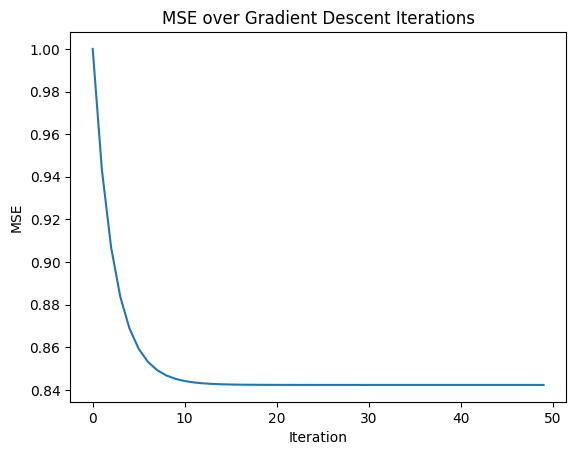

In [172]:
# Q5 — Find and fix the 3 bugs in this gradient descent implementation

# Data preparation
gd_X = heart_df["age"].values.astype(float)
gd_y = heart_df["thalachh"].values.astype(float)

# Normalize
gd_X = (gd_X - gd_X.mean()) / gd_X.std()
gd_y = (gd_y - gd_y.mean()) / gd_y.std()

# Initialize parameters
theta_0, theta_1 = 0.0, 0.0
learning_rate = 0.1
num_iterations = 50
m=len(gd_X)
mse_history = []

for iteration in range(num_iterations):
    # Predict
    y_pred = theta_0 + theta_1 * gd_X

    # Compute errors
    errors = y_pred - gd_y

    # BUG 1 is somewhere in the MSE calculation
    mse = np.mean(errors**2)
    mse_history.append(mse)

    # BUG 2 is somewhere in the theta_0 update
    theta_0 = theta_0 - learning_rate * (2*np.mean(errors)) #here it is the derivative of cost function with respect to theta_0 not just the mean squared errors 

    # BUG 3 is somewhere in the theta_1 update
    theta_1 = theta_1 - learning_rate * (2*np.mean(errors*gd_X))#here it is the derivative of cost function with respect to theta_1 not just the mean squared errors

print(f"Final MSE: {mse_history[-1]:.4f}")
plt.plot(mse_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE over Gradient Descent Iterations")
plt.show()


### Q6 — MAE vs MSE: Manual Computation (5 pts)

Using the `heart_df`, fit a `LinearRegression` to predict `thalach` (max heart rate) from `age`.

**Tasks:**
1. Fit the model on the full `heart_df` (1 pt)
2. Compute **MAE** manually (without sklearn): `np.mean(np.abs(y - y_pred))` (1 pt)
3. Compute **MSE** manually (without sklearn): `np.mean((y - y_pred) ** 2)` (1 pt)
4. Print both values (1 pt)
5. Answer in markdown: *"If one patient had an actual max heart rate of 200 but the model predicted 100, which metric (MAE or MSE) would be more affected by this single outlier, and why?"* (1 pt)

In [173]:
# Q6 — Your code here
from sklearn.linear_model import LinearRegression

model=LinearRegression()
lr=model.fit(X_train,y_train)
pred_y=model.predict(X_test)
mae=np.mean(np.abs(y_test - pred_y))
mse=np.mean((y_test - pred_y) ** 2)
mae,mse



(np.float64(0.28758027003966674), np.float64(0.12414794706828508))

*✏️ Your outlier answer here:#answer: If one patient has an actual hart rate of 200 but the model predicted 100, then the error is 100 so for mae it is 100 but for mean squared error it is 100**2 which is 10000. so the mse penalizes the large errors. so mse would be more affected but this outlier.
*


### Q7 — Z-Score Normalization (5 pts)

**Tasks:**
1. Apply z-score normalization to `thalach`: `(thalach - mean) / std` (2 pts)
2. Fit a `LinearRegression` on `age` (raw, not normalized) vs `thalach` (normalized) (1 pt)
3. Print the model's `coef_` and `intercept_` (1 pt)
4. In markdown: what does the `intercept_` represent when the target is normalized? (1 pt)

In [174]:
# Q7 — Your code here
heart_df["thalachh_zscore"]=(heart_df["thalachh"]- heart_df["thalachh"].mean())/heart_df["thalachh"].std()
X=heart_df[["age"]]
y_tha=heart_df["thalachh_zscore"]
X_train, X_test, y_train, y_test = train_test_split(
   X , y_tha, test_size=0.2, random_state=42)
model=LinearRegression()
lr=model.fit(X_train,y_train)
lr.coef_,lr.intercept_

(array([-0.04471053]), np.float64(2.420182312037743))

*✏️ Your intercept answer here:2.420182312037743*


---
## Section 3: Logistic Regression & Classification Metrics (25 pts)
*Estimated time: ~12 minutes*

---

### Q8 — Logistic Regression with Two Features (4 pts)

In class, we trained a `LogisticRegression` on `social_df` using **only Age**. Now let's try both features.

**Tasks:**
1. Use **both** `Age` AND `EstimatedSalary` as features, `Purchased` as target (1 pt)
2. Train-test split: 80/20, `random_state=42` (1 pt)
3. Train a `LogisticRegression` and print the `classification_report` on the **test** set (1 pt)
4. In markdown: does adding `EstimatedSalary` improve results compared to using only `Age`? Why might that be? (1 pt)

**⚠️ Store your social network variables as `social_X_train, social_X_test, social_y_train, social_y_test` and the model as `social_model` — used in Q9-Q11.**

In [177]:
# Q8 — Your code here
from sklearn.linear_model import LogisticRegression
X=social_df[["Age","EstimatedSalary"]]
y=social_df["Purchased"]
social_X_train,social_X_test,social_y_train,social_y_test= train_test_split(X,y,test_size=0.2,random_state=42)
social_model=LogisticRegression()
social_model.fit(social_X_train,social_y_train)
y_pred=social_model.predict(social_X_test)







In [178]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [58, 80]

*✏️ Your comparison answer here: yes the results improved,because earlier we were using only single information which is age to predict, if the user purchases the ad or not. But when more information like the estimated salary was given, model was able to gain more predictive signals, allowing it seperate from buyers and non buyers, when compared to only one feature. *


### Q9 — Manual Confusion Matrix (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predictions on the test set (1 pt)
2. Manually compute **TP, TN, FP, FN** using the boolean indexing pattern from class (2 pts):  
   `tp = y_test[(y_test == 1) & (y_pred == 1)].sum()`
3. Manually compute **precision** and **recall** from your TP/TN/FP/FN values (1 pt)
4. Verify your manual values match `precision_score()` and `recall_score()` from sklearn — print both to confirm (1 pt)

In [ ]:
# Q9 — Your code here
tp = ((y_test == 1) & (y_pred == 1)).sum()
tn=((y_test==0)&(y_pred==0)).sum()
fp=((y_test==0)&(y_pred==1)).sum()
fn=((y_test==1)&(y_pred==0)).sum()

precision=tp/(tp+fp)
recall=tp/(tp+fn)
precision, recall 


(np.float64(0.9130434782608695), np.float64(0.75))

### Q10 — Threshold Tuning (6 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predicted probabilities using `predict_proba()` — use the **positive class** column (1 pt)
2. Sweep thresholds from **0.0 to 1.0** in steps of **0.05** (1 pt)
3. For each threshold, convert probabilities to predictions using: `[1 if p >= threshold else 0 for p in probs]` (1 pt)
4. Compute precision and recall at each threshold (1 pt)
5. Plot **precision** and **recall** as two lines against threshold (1 pt)
6. In markdown: At approximately what threshold do precision and recall cross? What does this crossing point mean for the Social Network Ads business case? (1 pt)

1


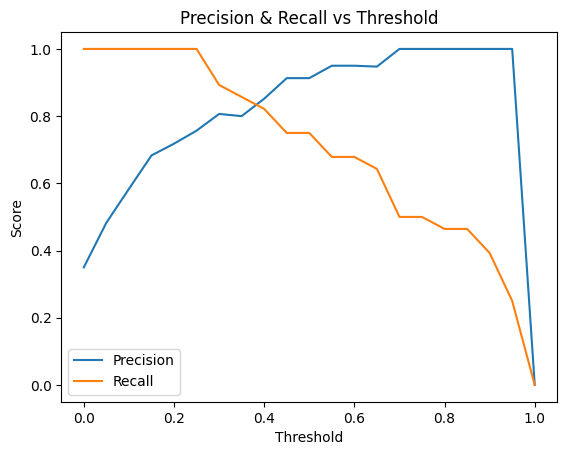

In [ ]:
# Q10 — Your code here
X=social_df[["Age","EstimatedSalary"]]
y=social_df["Purchased"]

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(X_train,y_train)
probs = model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.0, 1.0001, 0.05)
precisions=[]
recalls=[]


for i in thresholds:
    y_pred = np.array([1 if p >= i else 0 for p in probs])
    tp = ((y_test == 1) & (y_pred == 1)).sum()
    fp = ((y_test == 0) & (y_pred == 1)).sum()
    fn = ((y_test == 1) & (y_pred == 0)).sum()
    tn = ((y_test == 0) & (y_pred == 0)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precisions.append(precision)
    recalls.append(recall)

# 5) plot precision and recall vs threshold
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()








*✏️ Your threshold analysis here: At 0.4 threshold both the precision and recall meet. It means this is the point at which both the precision and recall are balanced. which means at this point we see balanced false positives and false negatives. which is important for business outcomes. *


### Q11 — Precision-Recall Curve & AUC (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Compute the precision-recall curve using `precision_recall_curve()` from sklearn (1 pt)
2. Compute the **AUC** (Area Under Curve) using `auc(recall, precision)` (1 pt)
3. Compute the **no-skill baseline**: `len(y_test[y_test == 1]) / len(y_test)` (1 pt)
4. Plot the PR curve with the no-skill baseline as a horizontal dashed line. Include labels and a legend. (1 pt)
5. In markdown: what does a higher AUC value tell you about your model? What would an AUC of 0.5 mean? (1 pt)

PR AUC: 0.941390910310929
No-skill baseline: 0.35


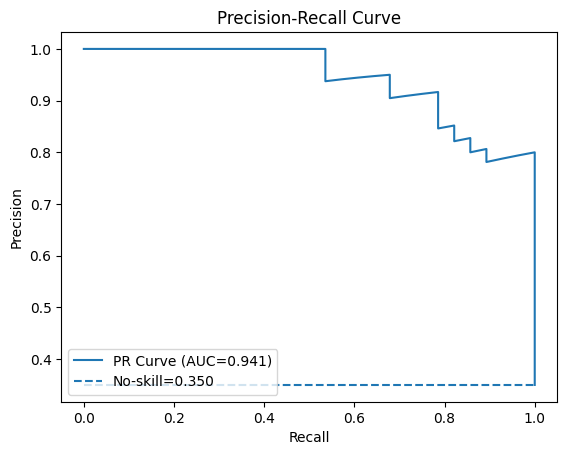

In [ ]:
# Q11 — Your code here
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)
no_skill_baseline= len(y_test[y_test == 1]) / len(y_test)

print("PR AUC:", pr_auc)
print("No-skill baseline:", no_skill_baseline)

plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.3f})")
plt.hlines(no_skill_baseline, xmin=0, xmax=1, linestyles="dashed", label=f"No-skill={no_skill_baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


*✏️ Your AUC analysis here:A higher AUC value indicates that the model has better ability to distinguish between positive and negative classes across different thresholds. It means the model maintains high precision while also achieving high recall, showing strong classification performance.

An AUC of 0.5 means the model didn't perform well on the test set, performs similar to random guessing. *


### Q12 — The Hospital Dilemma (5 pts)

A hospital builds a model to predict **heart disease** using the `heart_df` dataset. The model achieves:
- **Precision: 95%**
- **Recall: 60%**

The hospital administrator says:  
> *"This is great! When we say someone has heart disease, we're right 95% of the time."*

A doctor disagrees and says the model is **dangerous**.

**Tasks:**
1. Who is correct — the administrator or the doctor? Explain your reasoning. (2 pts)
2. What does 60% recall **actually mean** in terms of real patients? How many sick patients are being missed? (1 pt)
3. Which metric matters more for this use case — precision or recall? Why? (1 pt)
4. Name **one concrete action** you would take to improve recall (e.g., threshold adjustment, more data, different model). (1 pt)

*✏️ Your answer here: From the given data, precision looks good but the recall is kind of small. which means false positive is small but the false negative is high. It means when the disease is there , the model is saying no which is really dangerous. It might life of the patient.*


1. Doctor is correct, because recall is low when the false negatives is high. which means the model is missing the true patients. as the doctor is always concerned about the true patients more and that is the reason the doctor felt the model was dangerous. 
2. if there are 100 patients for example, the model might correctly predict only 60% pateint and miss 40% of the patients which is 40 patients with disease. which is really risky.
3. Here Precision and Recall both are important to improve the quality of the model. but more importantly we need to have high recall to safe the lives. 
4. One concrete action would be reducing the threshold value, so more positive values will be predicted. This helps in reducing the false negatives which indireclty improves the recall.

---
## Section 4: Tree-Based Models (25 pts)
*Estimated time: ~12 minutes*

---

### Q13 — Decision Tree Visualization & Feature Importance (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `DecisionTreeClassifier` with `max_depth=3` and `random_state=42` (1 pt)
2. Visualize the tree using `plot_tree()` with `filled=True`, `feature_names`, and `class_names=["No Disease", "Disease"]` (2 pts)
3. Print `feature_importances_` as a pandas Series, sorted from highest to lowest (2 pts)
4. In markdown: which feature is the most important? Does this make intuitive medical sense? (1 pt)

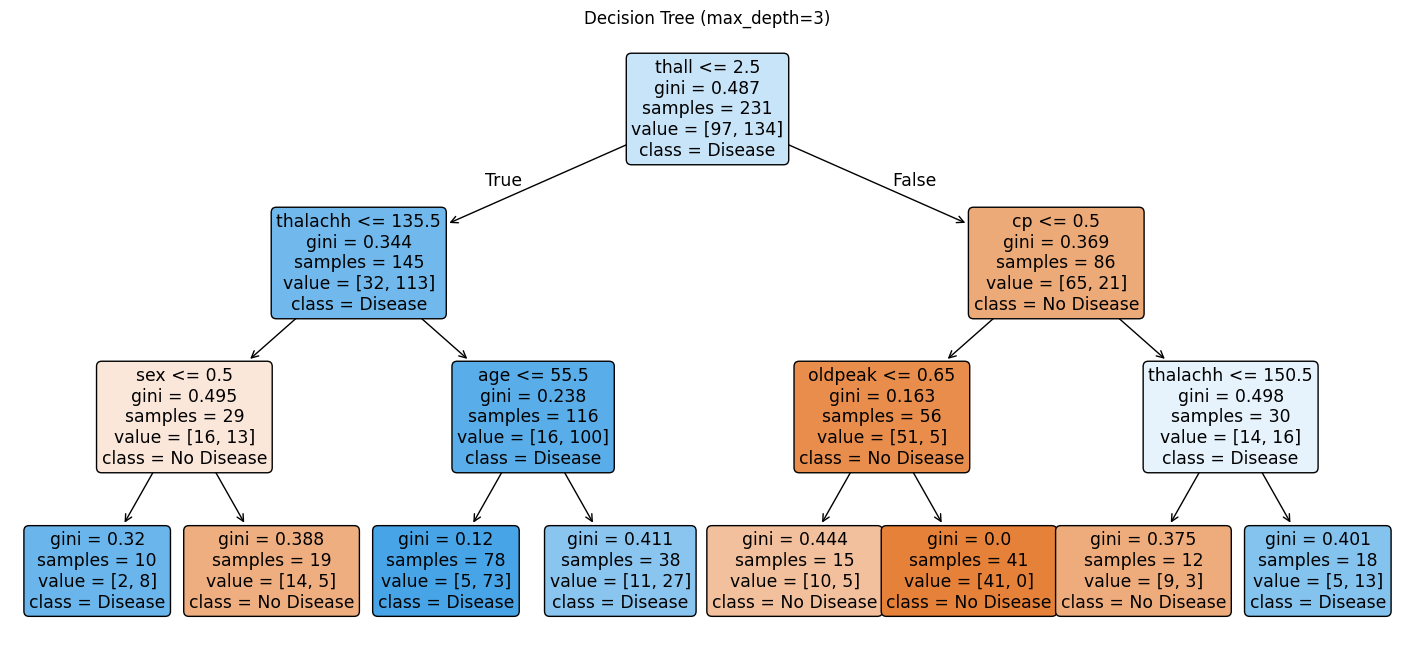

thall       0.527689
thalachh    0.190410
cp          0.131487
sex         0.064456
age         0.044303
oldpeak     0.041654
trtbps      0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
exng        0.000000
slp         0.000000
caa         0.000000
dtype: float64


In [ ]:
# Q13 — Your code here
from sklearn.tree import DecisionTreeClassifier 
X=heart_df.drop(columns=["output"])
y=heart_df["output"]
X_train, X_test, y_train, y_test = train_test_split(
   X , y, test_size=0.2, random_state=42
) 

model= DecisionTreeClassifier(max_depth=3,random_state=42 )
model.fit(X_train,y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    rounded=True
)
plt.title("Decision Tree (max_depth=3)")
plt.show()

# 3) Feature importances as a sorted pandas Series
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)


*✏️ Your feature importance analysis here: If we look at the feature importance values, most of the features has zero importance, and very few has really less values. so actual importance of the fatures only lies in the thall,thalachh, and cp.*


### Q14 — predict vs predict_proba (6 pts)

Using the decision tree from Q13:

**Tasks:**
1. Create a DataFrame with the following columns for the **first 10 test samples** (3 pts):
   - `Actual` — true labels from `y_test`
   - `Predicted` — model predictions
   - `Prob_No_Disease` — probability of class 0
   - `Prob_Disease` — probability of class 1
2. Display the DataFrame (1 pt)
3. Find the sample where the model is **least confident** (probability closest to 0.5). Print its index and probabilities. (1 pt)
4. In markdown: what does it mean when `predict_proba` gives [0.5, 0.5]? How does the decision tree produce these probabilities? (1 pt)

In [ ]:
# Q14 — Your code here
pred = model.predict(X_test)
proba = model.predict_proba(X_test)

test_samples=X_test.index[:10]
df_first10 = pd.DataFrame({
    "Actual": y_test.loc[test_samples].values,
    "Predicted": pred[:10],
    "Prob_No_Disease": proba[:10, 0],
    "Prob_Disease": proba[:10, 1],
}, index=test_samples)

df_first10
p_disease = proba[:, 1]
least_conf_i = np.argmin(np.abs(p_disease - 0.5))

least_conf_index = X_test.index[least_conf_i]
least_conf_probs = proba[least_conf_i]

print("Least confident test sample index:", least_conf_index)
print("Probabilities [No Disease, Disease]:", least_conf_probs)
print("Prob_Disease:", least_conf_probs[1])

Least confident test sample index: 113
Probabilities [No Disease, Disease]: [0.66666667 0.33333333]
Prob_Disease: 0.3333333333333333


*✏️ Your predict_proba explanation here:when the predict_proba is [0.5,0.5] then it means the probability of disease and no_disease is 50%. This happens only when the data has equal number of Disease and no Disease class.*


### Q15 — Ensemble Showdown: DT vs RF vs GB (7 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train all three models (3 pts):
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(n_estimators=20, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=20, random_state=42)`
2. Print the **test accuracy** for each model using `accuracy_score` (1 pt)
3. Create a **bar plot** comparing the three accuracies (1 pt)
4. In markdown, answer BOTH: (2 pts)
   - What is **bagging** and how does Random Forest use it?
   - What is the key difference between **bagging** (Random Forest) and **boosting** (Gradient Boosting)?

In [ ]:
# Q15 — Your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X=heart_df.drop(columns=["output"])
y=heart_df["output"]
X_train, X_test, y_train, y_test = train_test_split(
   X , y, test_size=0.2, random_state=42
) 

# Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",20
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [ ]:
dt_acc = accuracy_score(y_test, model.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))
gb_acc = accuracy_score(y_test, gb.predict(X_test))

print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)
print("Gradient Boosting Accuracy:", gb_acc)

Decision Tree Accuracy: 0.7413793103448276
Random Forest Accuracy: 0.8275862068965517
Gradient Boosting Accuracy: 0.8275862068965517


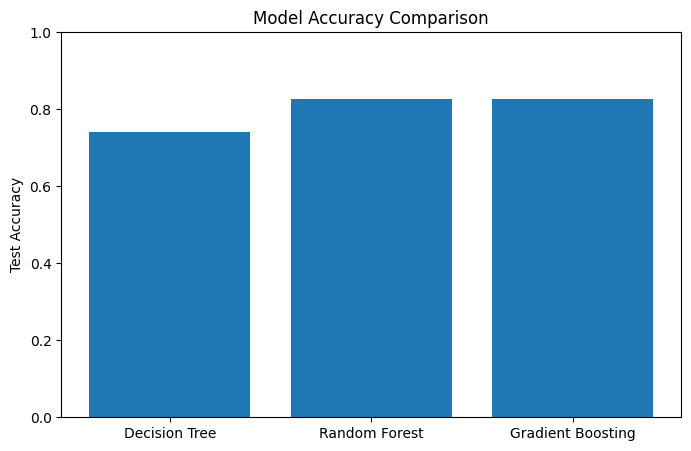

In [ ]:
models = ["Decision Tree", "Random Forest", "Gradient Boosting"]
accuracies = [dt_acc, rf_acc, gb_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

*✏️ Your bagging vs boosting explanation here: bagging and boosting are the two different concepts, where in bagging we train multiple models on different bootstrap samples.these models see few different samples from the rest. and predictions are averaged and the final prediction is made. But in boosting,trains trees sequentially. Each new tree focuses on correcting the errors made by the previous trees. This reduces bias by gradually improving weak learners. *


### Q16 — Overfitting Experiment (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `RandomForestClassifier(n_estimators=20, random_state=42)` with each `max_depth` in: `[2, 3, 5, 10, None]` (2 pts)
2. For each, record the **train accuracy** and **test accuracy** (1 pt)
3. Plot both curves on the same graph (x-axis = max_depth, y-axis = accuracy). Use labels and a legend. Replace `None` with a label like `"None"` on the x-axis. (2 pts)
4. In markdown: at which `max_depth` does overfitting start? How can you tell? (1 pt)

In [ ]:
# Q16 — Your code here
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

depths = [2, 3, 5, 10, None]

train_acc = []
test_acc = []

for d in depths:
    rf = RandomForestClassifier(
        n_estimators=20,
        max_depth=d,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

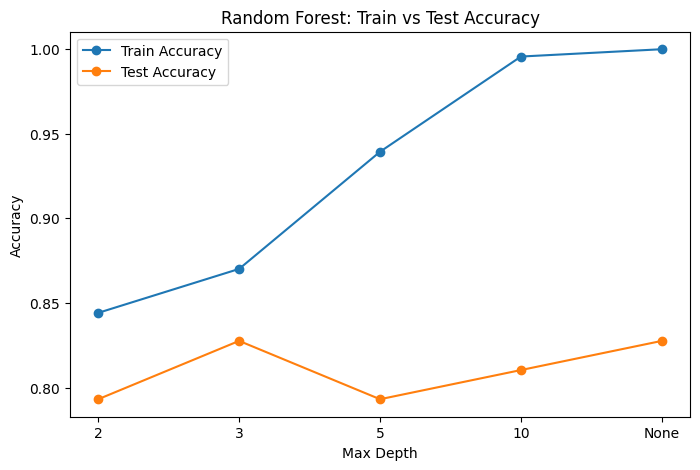

In [ ]:
# Replace None with string for plotting
depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(8,5))
plt.plot(depth_labels, train_acc, marker='o', label="Train Accuracy")
plt.plot(depth_labels, test_acc, marker='o', label="Test Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Random Forest: Train vs Test Accuracy")
plt.legend()
plt.show()

*✏️ Your overfitting analysis here:at max depth=3 the overfitting has started where the train accuracy gradually increased with depth.*


---
## Section 5: Model Pipeline & Deployment (10 pts)
*Estimated time: ~8 minutes*

---

### Q17 — Model Serialization with joblib (3 pts)

**Tasks:**
1. Take the **best-performing model** from Q15 (whichever had the highest test accuracy) (1 pt)
2. Save it to `"data/quiz_best_model.pkl"` using `joblib.dump()` (1 pt)
3. Load it back with `joblib.load()`, run predictions on `X_test`, and verify they match the original predictions using `np.array_equal()`. Print the result. (1 pt)

In [ ]:
# Q17 — Your code here

import joblib

joblib.dump(rf, "data/quiz_best_model.pkl")

['data/quiz_best_model.pkl']

In [ ]:
loaded_model = joblib.load("data/quiz_best_model.pkl")
# Original predictions
original_preds = rf.predict(X_test)

# Loaded model predictions
loaded_preds = loaded_model.predict(X_test)

# Check if they are identical
are_equal = np.array_equal(original_preds, loaded_preds)
are_equal


True

### Q18 — FastAPI Design (4 pts)

You want to deploy your heart disease model as a REST API using **FastAPI**.

**Tasks — answer in the markdown cell below (pseudocode/code is fine, it doesn't need to run):**

1. Write a **Pydantic `BaseModel`** class called `HeartFeatures` with all 13 feature fields from `heart.csv`, using appropriate types (`int` or `float`). (1 pt)
2. Write a `POST /predict` endpoint that: accepts `HeartFeatures`, converts it to a DataFrame, runs the model prediction, and returns `{"prediction": 0 or 1, "probability": float}`. (1 pt)
3. What **logging** would you add to this endpoint? List at least 3 log messages with their appropriate levels (DEBUG, INFO, WARNING, ERROR, CRITICAL). (1 pt)
4. What **error handling** would you add? Describe at least 2 scenarios that could go wrong and how you'd handle them. (1 pt)

In [ ]:
# Q18 — FastAPI Design (markdown / pseudocode)

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import joblib
import logging

app = FastAPI()

# ---- logging setup (simple) ----
logger = logging.getLogger("heart_api")
logger.setLevel(logging.INFO)

# ---- load model once at startup ----
model = joblib.load("data/quiz_best_model.pkl")

# 1) Pydantic model with 13 feature fields (NOT including output)
class HeartFeatures(BaseModel):
    age: int
    sex: int
    cp: int
    trtbps: int
    chol: int
    fbs: int
    restecg: int
    thalachh: int
    exng: int
    oldpeak: float
    slp: int
    caa: int
    thall: int


# 2) POST /predict endpoint
@app.post("/predict")
def predict(features: HeartFeatures):
    try:
        # DEBUG: input received (careful in real apps—avoid logging sensitive info)
        logger.debug(f"Received request: {features.model_dump()}")

        # Convert to DataFrame (1 row)
        X = pd.DataFrame([features.model_dump()])

        # Predict class
        pred = int(model.predict(X)[0])

        # Predict probability of class 1 ("Disease") if available
        if hasattr(model, "predict_proba"):
            prob_disease = float(model.predict_proba(X)[0][1])
        else:
            prob_disease = None  # some models may not support predict_proba

        # INFO: successful prediction
        logger.info(f"Prediction success pred={pred} prob={prob_disease}")

        return {"prediction": pred, "probability": prob_disease}

    except Exception as e:
        # ERROR: unexpected failure
        logger.error(f"Prediction failed: {str(e)}", exc_info=True)
        raise HTTPException(status_code=500, detail="Internal server error")

*✏️ Your FastAPI design here: HeartFeatures = HeartFeatures(BaseModel):
    age: int
    sex: int
    cp: int
    trtbps: int
    chol: int
    fbs: int
    restecg: int
    thalachh: int
    exng: int
    oldpeak: float
    slp: int
    caa: int
    thall: int
*


### Q19 — Load Testing Design (3 pts)

You've deployed your heart disease API and need to verify it can handle traffic.

**Tasks — answer in the markdown cell below:**

1. What Python library/class would you use to send **500 concurrent requests**? (1 pt)
2. Write a function signature `run_load_test(num_requests: int)` and describe in pseudocode what it does (generate random data, send requests, collect results). (1 pt)
3. What **3 metrics** would you collect and report at the end of the load test? (1 pt)

*✏️ Your load testing design here:*


---
## Section 6: Boss Level — End-to-End Challenge (10 pts)
*Estimated time: ~8 minutes*

---

### Q20 — Full ML Pipeline (10 pts)

Using `social_df`, build a **complete ML pipeline** from scratch:

1. **Feature Engineering (2 pts):** Create at least **one new feature** (e.g., `Age_Salary_Ratio = Age / EstimatedSalary`, or binning Age into groups, or any creative transformation). Use both `Age` and `EstimatedSalary` plus your new feature(s) as inputs.

2. **Model Training (2 pts):** Train a `GradientBoostingClassifier` on your features.

3. **Threshold Optimization (2 pts):** Using `predict_proba`, find the threshold that maximizes the **F1 score** (hint: F1 = 2 * precision * recall / (precision + recall)). Print the optimal threshold and the F1 at that threshold.

4. **Final Evaluation (2 pts):** Apply your optimal threshold to the test set predictions. Print the `classification_report` at your chosen threshold.

5. **Save & Report (2 pts):**
   - Save the model to `"data/quiz_boss_model.pkl"` using joblib
   - In a markdown cell below, write a **3-sentence model report** explaining: what features you used, what threshold you chose and why, and how the model performed.

In [ ]:
X_raw = social_df.drop(columns=["Purchased"]).copy()
y = social_df["Purchased"].copy()
sorted(social_df["Age"].unique())

[np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60)]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report
import joblib, os

# ----- Age grouping -----
bins = [0, 30, 40, 50, 200]  # safer bins (covers all ages)
social_df["Age_Group"] = pd.cut(
    social_df["Age"],
    bins=bins,
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

# ----- Split -----
X_raw = social_df[["Age", "EstimatedSalary", "Age_Group"]].copy()
y = social_df["Purchased"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Create validation split from training data (for threshold tuning)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# ----- Train -----
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_tr, y_tr)

# ----- Threshold optimization on VAL -----
val_probs = gb.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.0, 1.0, 1001)
best_t, best_f1 = 0.5, -1.0

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold:", best_t)
print("Best validation F1:", best_f1)

# ----- Final evaluation on TEST -----
test_probs = gb.predict_proba(X_test_raw)[:, 1]
test_pred_opt = (test_probs >= best_t).astype(int)

print("\nClassification report on TEST (optimal threshold):")
print(classification_report(y_test, test_pred_opt, zero_division=0))

# ----- Save model -----
os.makedirs("data", exist_ok=True)
joblib.dump(gb, "data/quiz_boss_model.pkl")
print("\nSaved model to data/quiz_boss_model.pkl")

Best threshold: 0.084
Best validation F1: 0.9310344827586207

Classification report on TEST (optimal threshold):
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        51
           1       0.75      0.93      0.83        29

    accuracy                           0.86        80
   macro avg       0.85      0.88      0.86        80
weighted avg       0.88      0.86      0.86        80


Saved model to data/quiz_boss_model.pkl


*✏️ Your 3-sentence model report here: trained a Gboostingclassifier using Age, EstimatedSalary, and an engineered Age_Group feature to capture life-stage purchasing behavior.
The optimal probability threshold was 0.084, selected because it maximized the validation F1 score (0.93), prioritizing a strong balance between precision and recall.
On the test set, the model achieved 86% accuracy, with particularly strong recall for the positive class (0.93), indicating it effectively identifies likely purchasers while maintaining solid overall performance.*


---

## You're Done!

**Before submitting:**
1. **Restart the kernel** and **Run All Cells** — make sure everything runs without errors
2. Check that all markdown answers are filled in (search for `✏️`)
3. Save the notebook

**Good work!** 🎉